In [1]:
# Setup and IBM backend connection

from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from time import sleep
from broadcasting import generate_qiskit_circuit, add_fidelity
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from datetime import datetime

np.set_printoptions(linewidth=200, precision=3, suppress=True)

# service = QiskitRuntimeService(name="mprest1")
service = QiskitRuntimeService()

management.get:WARNING:2026-04-30 10:26:25,011: Loading default saved account
qiskit_runtime_service.__init__:WARNING:2026-04-30 10:26:30,292: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: mprest1. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


State: Ry(2.4315) Rz(2.7576) |0⟩
Circuit depth (unbound): 36
Total qubits: 9  (5 data + 4 ancilla)


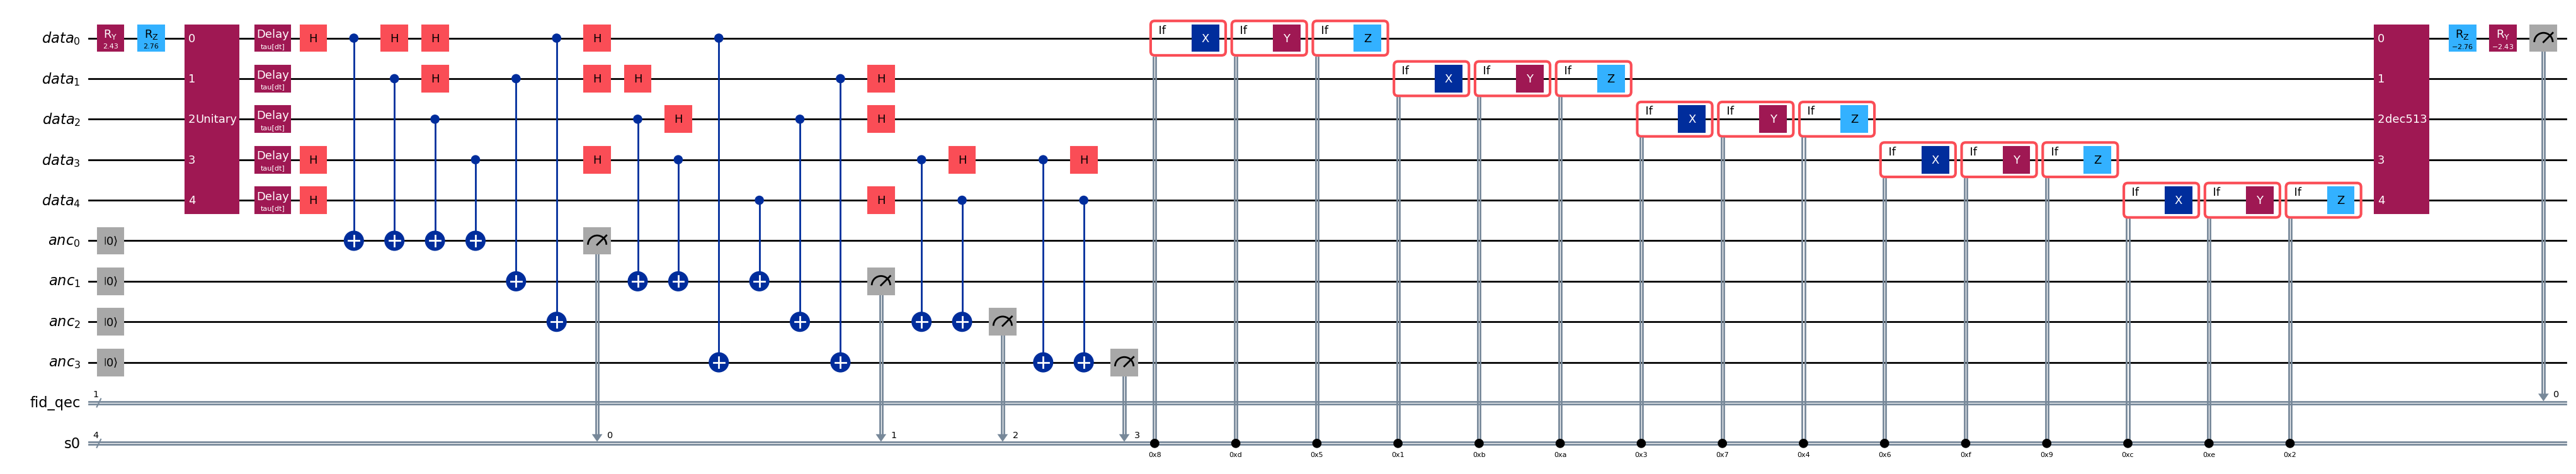

In [5]:

# QEC [[5,1,3]] fidelity benchmark
# Prepares a random phase state, encodes it into the [[5,1,3]] code, applies
# a parametric time delay, decodes (with syndrome correction), and measures
# the fidelity of the recovered qubit.

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from broadcasting.qec_513 import five_qubit_decode_gate, decode_qec_513
seed = 42
rng = np.random.default_rng(seed)

# --- Parameters ---
theta_qec = float(rng.uniform(0, np.pi))      # polar angle for |ψ⟩ = Ry(θ)|0⟩
phi_qec   = float(rng.uniform(0, 2 * np.pi))  # azimuthal angle (Rz(φ) applied after Ry)
tau_qec   = Parameter("tau")                   # delay duration in dt units
shots_qec = 8192

# --- Build the encode gate = adjoint of decode gate ---
decode_gate = five_qubit_decode_gate()
encode_gate = decode_gate.adjoint()   # maps |00000⟩ → |0_L⟩, |00001⟩ → |1_L⟩

# --- Registers ---
data = QuantumRegister(5, "data")         # [[5,1,3]] physical block
anc  = QuantumRegister(4, "anc")          # ancilla for syndrome measurement
fid  = ClassicalRegister(1, "fid_qec")   # fidelity readout

qc_qec = QuantumCircuit(data, anc, fid)

# 1. Prepare random phase state on data[0]
qc_qec.ry(theta_qec, data[0])
qc_qec.rz(phi_qec,   data[0])

# 2. Encode into [[5,1,3]] block
qc_qec.append(encode_gate, data[:])

# 3. Parametric delay on every physical qubit in the block
for q in data:
    qc_qec.delay(tau_qec, q)

# 4. Decode (syndrome extraction, classical feedforward, decode unitary)
#    Reuse the ancilla register we already added.
decoded_qubits = decode_qec_513(qc_qec, [list(data)], ancilla_qubits=list(anc))
decoded_q = decoded_qubits[0]   # index of the logical qubit after decoding

# 5. Inverse state preparation on decoded qubit → fidelity = P(|0⟩)
qc_qec.rz(-phi_qec,   decoded_q)
qc_qec.ry(-theta_qec, decoded_q)
qc_qec.measure(decoded_q, fid[0])

print(f"State: Ry({theta_qec:.4f}) Rz({phi_qec:.4f}) |0⟩")
print(f"Circuit depth (unbound): {qc_qec.depth()}")
print(f"Total qubits: {qc_qec.num_qubits}  (5 data + 4 ancilla)")
qc_qec.draw("mpl", fold=120)


Circuit depth (unbound): 33
Total qubits: 9  (5 data + 4 ancilla)


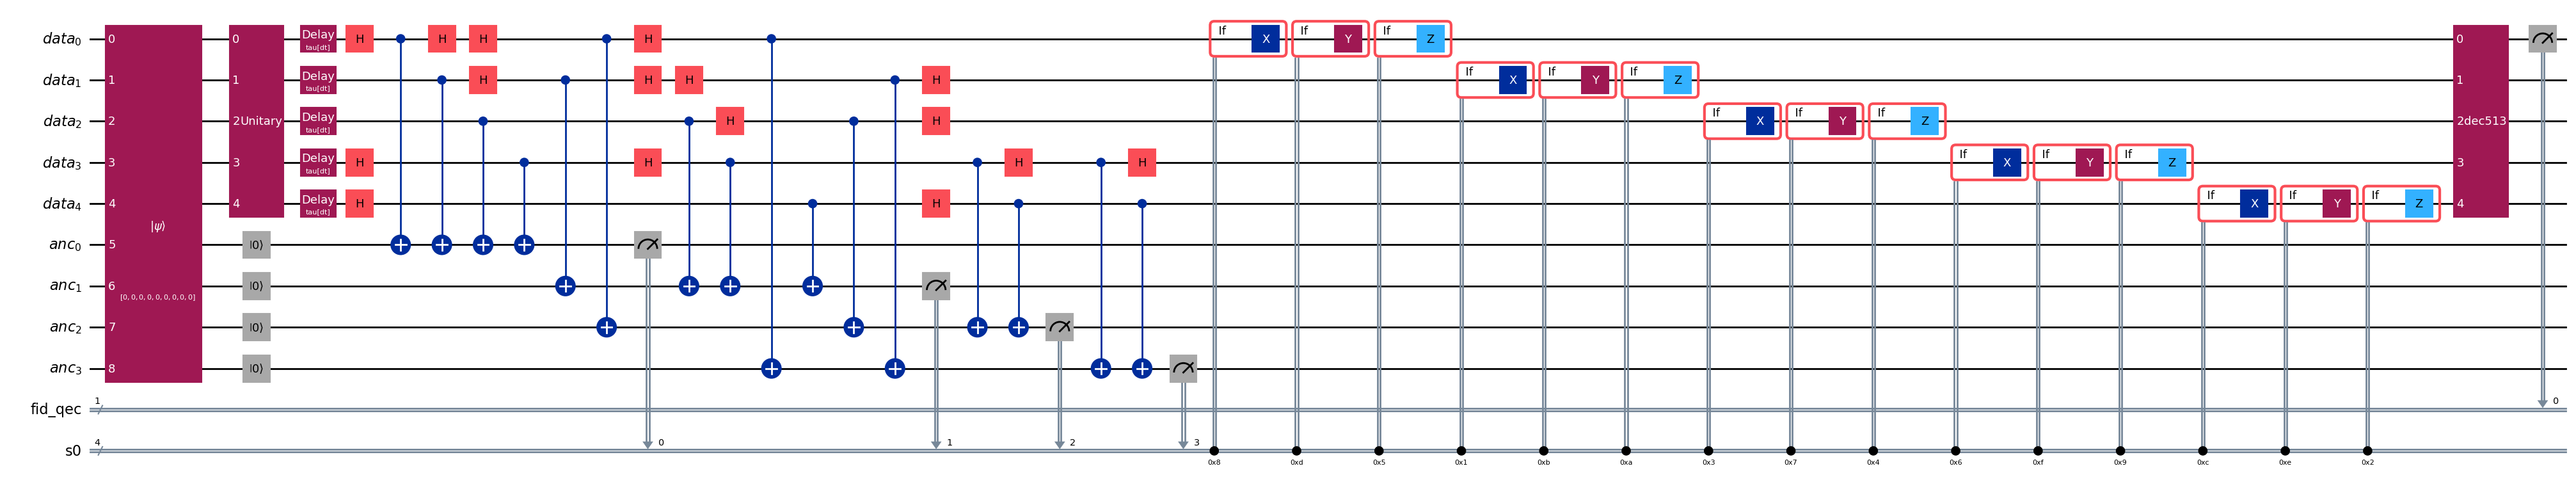

In [4]:

# QEC [[5,1,3]] fidelity benchmark
# Prepares a random phase state, encodes it into the [[5,1,3]] code, applies
# a parametric time delay, decodes (with syndrome correction), and measures
# the fidelity of the recovered qubit.

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from broadcasting.qec_513 import five_qubit_decode_gate, decode_qec_513
seed = 42
rng = np.random.default_rng(seed)

# --- Parameters ---
tau_qec   = Parameter("tau")                   # delay duration in dt units
shots_qec = 8192

# --- Build the encode gate = adjoint of decode gate ---
decode_gate = five_qubit_decode_gate()
encode_gate = decode_gate.adjoint()   # maps |00000⟩ → |0_L⟩, |00001⟩ → |1_L⟩

# --- Registers ---
data = QuantumRegister(5, "data")         # [[5,1,3]] physical block
anc  = QuantumRegister(4, "anc")          # ancilla for syndrome measurement
fid  = ClassicalRegister(1, "fid_qec")   # fidelity readout

qc_qec = QuantumCircuit(data, anc, fid)

# 1. Prepare 0 states
qc_qec.initialize('000000000')


# 2. Encode into [[5,1,3]] block
qc_qec.append(encode_gate, data[:])

# 3. Parametric delay on every physical qubit in the block
for q in data:
    qc_qec.delay(tau_qec, q)

# 4. Decode (syndrome extraction, classical feedforward, decode unitary)
#    Reuse the ancilla register we already added.
decoded_qubits = decode_qec_513(qc_qec, [list(data)], ancilla_qubits=list(anc))
decoded_q = decoded_qubits[0]   # index of the logical qubit after decoding

# 5. Inverse state preparation on decoded qubit → fidelity = P(|0⟩)
qc_qec.measure(decoded_q, fid[0])

print(f"Circuit depth (unbound): {qc_qec.depth()}")
print(f"Total qubits: {qc_qec.num_qubits}  (5 data + 4 ancilla)")
qc_qec.draw("mpl", fold=120)


M=1, N=2, QEC=False
nt=1 theta samples, 41 tau values -> 41 circuits
Theta samples (radians):
  [0] [4.863]


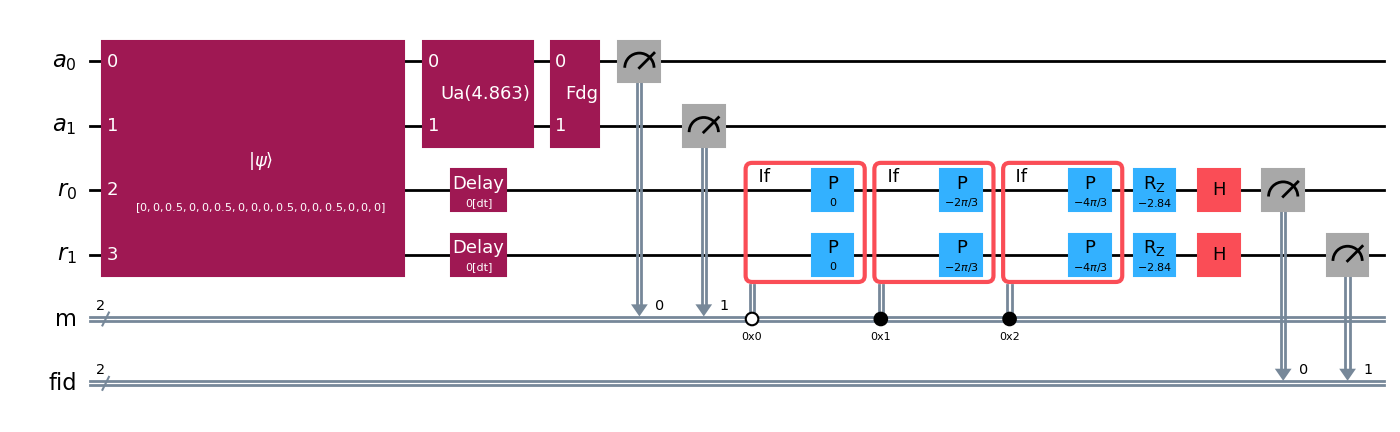

In [2]:
# Protocol parameters
M_senders = 1
N_receivers = 2
use_qec = False
shots = 8192
seed = 42

# Theta sweep: nt random samples per sender, uniform on [0, 2pi)
nt = 1
rng = np.random.default_rng(seed)
theta_samples = rng.uniform(0, 2 * np.pi, size=(nt, M_senders))

# Tau delay sweep (backend dt units). Use [0] to skip the delay dimension.
# tau_values = np.array([0])
tau_values = np.linspace(0, 6000, 41)

# Build one circuit per theta sample, bind tau for each
circuits = []
run_index = []  # (theta_idx, tau_val) for each circuit

for ti, thetas in enumerate(theta_samples):
    qc = generate_qiskit_circuit(
        M_senders, N_receivers, thetas.tolist(),
        use_receiver_qec_513=use_qec,
    )
    qc, reg_name, phi = add_fidelity(qc, N=N_receivers, thetas=thetas.tolist())
    tau_param = next(p for p in qc.parameters if p.name == "tau")

    for tau in tau_values:
        bound = qc.assign_parameters({tau_param: int(tau)})
        circuits.append(bound)
        run_index.append((ti, int(tau)))

print(f"M={M_senders}, N={N_receivers}, QEC={use_qec}")
print(f"nt={nt} theta samples, {len(tau_values)} tau values -> {len(circuits)} circuits")
print(f"Theta samples (radians):")
for ti, thetas in enumerate(theta_samples):
    print(f"  [{ti}] {thetas}")

# Printing circuit details for the first theta sample
circuits[0].draw("mpl", fold=100)

In [39]:
# Transpile and submit to backend
backend = service.least_busy(simulator=False, operational=True)
print(f"Backend: {backend.name}")

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)
pubs = [(isc,) for isc in isa_circuits]
job = sampler.run(pubs, shots=shots)
print(f"Job ID: {job.job_id()}")
print(f"Circuits submitted: {len(pubs)}")
sleep(10)
print(f"Status: {job.status()}")

Backend: ibm_fez
Job ID: d7bc3ab0g7hs73dpd27g
Circuits submitted: 82
Status: RUNNING


In [40]:
# Extract results, compute fidelities, save to file
results = job.result()
all_results = {}

for idx, ((ti, tau), pub_result) in enumerate(zip(run_index, results)):
    fid_data = getattr(pub_result.data, reg_name)
    counts = fid_data.get_counts()
    total = sum(counts.values())

    # BitArray.get_counts() returns per-register bitstrings (no spaces).
    # Qiskit convention: creg[i] = position i from the RIGHT of the bitstring.
    # So bitstr[-1-i] or equivalently bitstr[N-1-i] gives creg[i].
    fidelities = []
    for i in range(N_receivers):
        p0 = sum(v for bs, v in counts.items() if bs[N_receivers - 1 - i] == "0") / total
        fidelities.append(p0)

    key = f"theta_{ti}_tau_{tau}"
    all_results[key] = {
        "theta_idx": ti,
        "thetas": theta_samples[ti].tolist(),
        "tau": tau,
        "fidelities": fidelities,
        "counts": counts,
    }

# Print results table
thetas_str = "  ".join(f"theta_{j}" for j in range(M_senders))
recv_str = "  ".join(f"recv_{i}" for i in range(N_receivers))
print(f"{'idx':>3}  {'tau':>5}  {thetas_str}  |  {recv_str}")
print("-" * (12 + 8 * M_senders + 3 + 8 * N_receivers))
for key, data in all_results.items():
    ti, tau = data["theta_idx"], data["tau"]
    ts = "  ".join(f"{t:6.3f}" for t in data["thetas"])
    fs = "  ".join(f"{f:.4f}" for f in data["fidelities"])
    print(f"{ti:>3}  {tau:>5}  {ts}  |  {fs}")

# Save to timestamped JSON
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
outfile = results_dir / f"run_{timestamp}.json"

run_data = {
    "timestamp": datetime.now().isoformat(),
    "job_id": job.job_id(),
    "backend": backend.name,
    "shots": shots,
    "seed": seed,
    "protocol": {
        "M": M_senders,
        "N": N_receivers,
        "use_qec": use_qec,
        "nt": nt,
        "theta_samples": theta_samples.tolist(),
        "tau_values": [int(t) for t in tau_values],
    },
    "results": {
        key: {
            "theta_idx": data["theta_idx"],
            "thetas": data["thetas"],
            "tau": data["tau"],
            "fidelities": data["fidelities"],
            "counts": data["counts"],
        }
        for key, data in all_results.items()
    },
}

with open(outfile, "w") as f:
    json.dump(run_data, f, indent=2)
print(f"\nResults saved to {outfile}")

idx    tau  theta_0  |  recv_0  recv_1
---------------------------------------
  0      0   4.863  |  0.9391  0.9053
  0    150   4.863  |  0.9113  0.9260
  0    300   4.863  |  0.9076  0.9274
  0    450   4.863  |  0.9395  0.9049
  0    600   4.863  |  0.9091  0.9243
  0    750   4.863  |  0.8906  0.8344
  0    900   4.863  |  0.9128  0.8823
  0   1050   4.863  |  0.8827  0.8492
  0   1200   4.863  |  0.8524  0.8204
  0   1350   4.863  |  0.7845  0.7987
  0   1500   4.863  |  0.7927  0.7626
  0   1650   4.863  |  0.7566  0.7244
  0   1800   4.863  |  0.7114  0.6914
  0   1950   4.863  |  0.6757  0.6571
  0   2100   4.863  |  0.6420  0.6206
  0   2250   4.863  |  0.6080  0.5981
  0   2400   4.863  |  0.5782  0.5757
  0   2550   4.863  |  0.8298  0.5062
  0   2700   4.863  |  0.5198  0.5182
  0   2850   4.863  |  0.4956  0.5070
  0   3000   4.863  |  0.8241  0.4344
  0   3150   4.863  |  0.4937  0.4951
  0   3300   4.863  |  0.5048  0.4918
  0   3450   4.863  |  0.4979  0.5011
  0   360